Cluster data (or go to cell 3 to load previously created data)

In [ ]:
from os_model.data_processing.multistate_sequence_clustering import create_data

kmers, targets = create_data('data/sequences.fa', kmer_size=100)

In [ ]:
import pickle

data = (kmers, targets)

with open('processed_data.pkl', 'wb') as o:
    pickle.dump(data, o)

Load the saved data

In [4]:
import pickle
with open('data/sequence_data/processed_data.pkl', 'rb') as i:
    data = pickle.load(i)

In [5]:
seqs, targets = data

Create dataset

In [6]:
from os_model.data_processing.multistate_genome_processing import GenomeDataset
dataset = GenomeDataset(seqs, targets=targets, mutants=False, embedding_func_mode='freq', quantum_mode='multistate', extra_seq=1, kmer_length=25, subkmer_length=2, step_size=25)

Started calculating 64 clusters for 70524 kmers


Check device

In [7]:
import torch
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
device 

device(type='cuda')

Define training parameters

In [8]:
n_muts=31
dataset.extra_seq=8
n_layers = 4
depth = 2

n_qubits = dataset.database_size
dataset.pick_extra_seq()
dataset.minibatch_size=dataset.extra_seq
if n_muts:
  dataset.minibatch_size=int(dataset.extra_seq*(n_muts+1))
  dataset.gen_mut_dataset(num_mutants=n_muts, mutation_ratio=0.05)
dataset.embedd_clusters(kmer_length=25, subkmer_length=2, step_size=25)

generating mutants


Train model

In [99]:
from os_model.models.HybridModel import HybridModel
from os_model.models.EmbeddingModel import EditDistanceModel
from torch.utils.data import DataLoader
import torch.optim as optim


# Step 4: Training the Hybrid Model
def train(model, data_loader, optimizer, loss_fn, epochs=None):
    if epochs:
      losses = []
      for epoch in range(epochs):
        for batch in data_loader:
                sequences, targets = batch
                sequences, targets = sequences.to(device), targets.to(device)
                optimizer.zero_grad()
                outputs = model(sequences)
                loss = loss_fn(outputs, targets)
                loss.backward()
                optimizer.step()
                print(f"Epoch {epoch+1}, Loss: {loss.item()}")
                losses.append(loss.item())
        if loss.item() < 0.08:
          break

 
def loss_fn(pred, target):    
    absolute_errors = torch.abs(pred - target)  # Element-wise absolute difference
    summed_errors = absolute_errors.sum(dim=1)  # Sum over each tensor (row-wise)
    mean_error = summed_errors.mean()  # Average over batch
    return mean_error

def custom_collate(batch):
    """Custom function to handle variable-length data"""
    data, targets = zip(*batch)  # Unzip batch into two lists
    data = torch.cat(data)
    targets = torch.cat(targets)  # Convert to tensor
    return data, targets

embedding_model = EditDistanceModel()
hybrid_model = HybridModel(embedding_model, n_qubits, n_layers, depth=depth, freeze_embed_model=False)
hybrid_model.to(device)


data_loader = DataLoader(dataset, batch_size=int(2**dataset.database_size), shuffle=True, pin_memory=True, collate_fn=custom_collate)

    
# Define optimizer and loss function
optimizer = optim.Adam(hybrid_model.parameters(), lr=0.005)

# Train the hybrid model
train(hybrid_model, data_loader, optimizer, loss_fn, epochs=1500)

generating mutants
Number of qubits: 6
Epoch 1, Loss: 1.969242641747249
Epoch 2, Loss: 1.925249590183129
Epoch 3, Loss: 1.8952716894175294
Epoch 4, Loss: 1.8505567556397966
Epoch 5, Loss: 1.7943949559858088
Epoch 6, Loss: 1.7457722391491506
Epoch 7, Loss: 1.705082393776089
Epoch 8, Loss: 1.6576762433919425
Epoch 9, Loss: 1.6145807455648988
Epoch 10, Loss: 1.5828534160104042
Epoch 11, Loss: 1.5459581288281414
Epoch 12, Loss: 1.5093052123342885
Epoch 13, Loss: 1.4746764759969428
Epoch 14, Loss: 1.4428724414640404
Epoch 15, Loss: 1.4290889997532408
Epoch 16, Loss: 1.403562377705406
Epoch 17, Loss: 1.3791513763173082
Epoch 18, Loss: 1.3591552640911735
Epoch 19, Loss: 1.3377212376770165
Epoch 20, Loss: 1.3123981022354227
Epoch 21, Loss: 1.2807678564886
Epoch 22, Loss: 1.2593844752239811
Epoch 23, Loss: 1.2374382713347634
Epoch 24, Loss: 1.2171149447899994
Epoch 25, Loss: 1.195213221635918
Epoch 26, Loss: 1.1776983284473475
Epoch 27, Loss: 1.1575419327756082
Epoch 28, Loss: 1.138045041489311

Evaluate Model

In [93]:
from os_model.models.eval import eval_model

In [ ]:
sr_t = eval_model(hybrid_model, dataset, n_eval=1, n_counts=100, mode='SR-TS')
sr_t

In [ ]:
sr_m = eval_model(hybrid_model, dataset, n_eval=32, n_counts=100, mode='SR-M')
sr_m

In [125]:
sr_i = eval_model(hybrid_model, dataset, n_eval=64, n_counts=100, mode='SR-IS')
sr_i

TypeError: cannot unpack non-iterable numpy.int32 object

In [9]:
from os_model.models.HybridModel import NewHybridModel
from os_model.models.EmbeddingModel import EditDistanceModel

embedding_model = EditDistanceModel()
hybrid_model = NewHybridModel(embedding_model, n_qubits, n_layers, depth=depth, freeze_embed_model=False)

In [10]:
hybrid_model

NewHybridModel(
  (embedding_model): EditDistanceModel(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (conv1): Conv1d(1, 1, kernel_size=(2,), stride=(1,))
    (bn1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc1): Linear(in_features=63, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=200, bias=True)
  )
  (connector_model): Classical2QuantumConnector(
    (relu): ReLU()
    (mlp): Sequential(
      (0): Linear(in_features=200, out_features=400, bias=True)
      (1): ReLU()
      (2): Linear(in_features=400, out_features=72, bias=True)
    )
  )
)

In [11]:
import torch
state_dict = torch.load('/home/illia/QML/OS-hQML/data/model_weights/model_dct_64_multistate_8extaseq_31mut_4ql_2ll_96_74_79.pth', weights_only=True)
for key in ["embedding_model.conv2.weight", "embedding_model.conv2.bias", "embedding_model.bn2.weight", "embedding_model.bn2.bias", "embedding_model.bn2.running_mean", "embedding_model.bn2.running_var", "embedding_model.bn2.num_batches_tracked", "embedding_model.bn3.weight", "embedding_model.bn3.bias", "embedding_model.bn3.running_mean", "embedding_model.bn3.running_var", "embedding_model.bn3.num_batches_tracked", "embedding_model.bn4.weight", "embedding_model.bn4.bias", "embedding_model.bn4.running_mean", "embedding_model.bn4.running_var", "embedding_model.bn4.num_batches_tracked", "embedding_model.fc2.weight", "embedding_model.fc2.bias", "embedding_model.fc.weight", "embedding_model.fc.bias"]:
    state_dict.pop(key)

In [12]:
hybrid_model.load_state_dict(state_dict)

<All keys matched successfully>

In [22]:
for param in hybrid_model.parameters():
    param.requires_grad = False

In [23]:
import random

def sample_n_data(n, dataset, mut_rate=0):
    data=random.choices(list(zip(dataset.input_kmers, dataset.input_targets)), k=n)
    x = []
    y = []
    for seq,target in data:
        if mut_rate:
            seq = dataset.random_mutations(seq, mut_rate)
        x.append(dataset.embedding_func(seq, kmer_length=25, subkmer_length=2, step_size=25))
        y.append(target)
    x = torch.stack(x)
    y = torch.stack(y)
    return x,y


In [13]:
hybrid_model.eval()

NewHybridModel(
  (embedding_model): EditDistanceModel(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (conv1): Conv1d(1, 1, kernel_size=(2,), stride=(1,))
    (bn1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc1): Linear(in_features=63, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=200, bias=True)
  )
  (connector_model): Classical2QuantumConnector(
    (relu): ReLU()
    (mlp): Sequential(
      (0): Linear(in_features=200, out_features=400, bias=True)
      (1): ReLU()
      (2): Linear(in_features=400, out_features=72, bias=True)
    )
  )
)

In [78]:
m = 0
s = 0.01
sr = []
mr = []
while m <= 0.1:
    n=20000
    x,y = sample_n_data(n, dataset, mut_rate=m)
    res = hybrid_model(x)*100
    r = sum(res.int()[y!=0])/n
    sr.append(r.item())
    mr.append(m)
    m+=s
    

In [79]:
sr, mr

([73.7281494140625,
  71.79620361328125,
  69.52635192871094,
  67.25855255126953,
  64.23314666748047,
  61.87525177001953,
  58.78379821777344,
  55.45000076293945,
  53.13045120239258,
  49.928550720214844,
  46.98699951171875],
 [0,
  0.01,
  0.02,
  0.03,
  0.04,
  0.05,
  0.060000000000000005,
  0.07,
  0.08,
  0.09,
  0.09999999999999999])

/tmp/ipykernel_11373/3561921841.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x=labels, y=bars, palette="viridis")


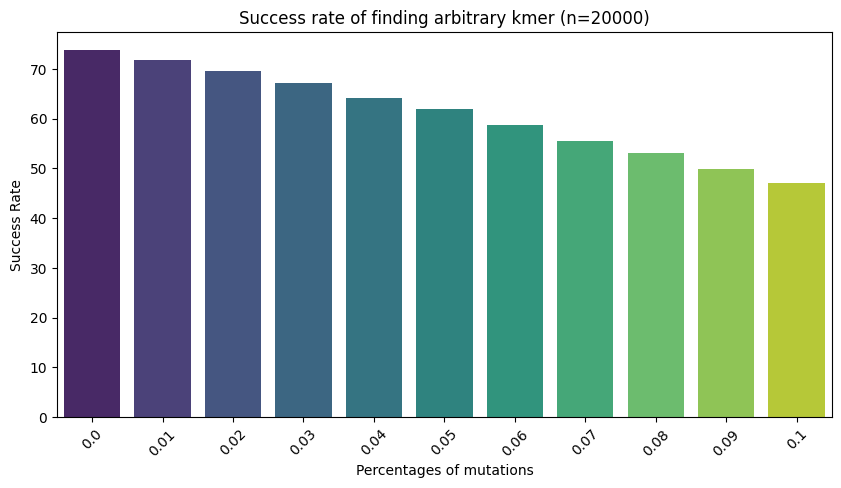

In [81]:
import matplotlib.pyplot as plt
import seaborn as sns
import numpy as np

# Example data
bars = sr  # Values for bars
labels = [round(i,2) for i in mr] # Labels for bars

# Plot
plt.figure(figsize=(10, 5))
sns.barplot(x=labels, y=bars, palette="viridis")

# Rotate labels for better visibility
plt.xticks(rotation=45)
plt.xlabel("Percentages of mutations")
plt.ylabel("Success Rate")
plt.title("Success rate of finding arbitrary kmer (n=20000)")

plt.show()


In [62]:
import time

t = time.time()
t1 = time.time()
t1-t

3.075599670410156e-05

In [87]:
m = 0
s = 0.01
ns = [1000, 10_000, 25_000, 50_000, 100_000]
ts_cpu = []
for n in ns:
    x,y = sample_n_data(n, dataset, mut_rate=0)
    t1 = time.time()
    res = hybrid_model(x)*100
    t2 = time.time()
    ts_cpu.append(t2-t1)

In [88]:
ts_cpu

[0.047753095626831055,
 0.3613600730895996,
 0.8596875667572021,
 1.7788081169128418,
 3.658625602722168]

In [14]:
hybrid_model.cuda()

NewHybridModel(
  (embedding_model): EditDistanceModel(
    (flatten): Flatten(start_dim=1, end_dim=-1)
    (conv1): Conv1d(1, 1, kernel_size=(2,), stride=(1,))
    (bn1): BatchNorm1d(1, eps=1e-05, momentum=0.1, affine=True, track_running_stats=True)
    (fc1): Linear(in_features=63, out_features=1024, bias=True)
    (fc3): Linear(in_features=1024, out_features=200, bias=True)
  )
  (connector_model): Classical2QuantumConnector(
    (relu): ReLU()
    (mlp): Sequential(
      (0): Linear(in_features=200, out_features=400, bias=True)
      (1): ReLU()
      (2): Linear(in_features=400, out_features=72, bias=True)
    )
  )
)

In [104]:
ns = [1000, 10_000, 25_000, 50_000, 100_000]
ts_gpu_total = []
ts_gpu_load = []
for n in ns:
    x,y = sample_n_data(n, dataset, mut_rate=0)
    t1 = time.time()
    x = x.cuda()
    t2 = time.time()
    res = hybrid_model(x)*100
    t3 = time.time()
    ts_gpu_total.append(t3-t1)
    ts_gpu_load.append(t2-t1)
    torch.cuda.empty_cache()
    

In [105]:
ts_gpu_total

[0.0423426628112793,
 0.0301516056060791,
 0.038208961486816406,
 0.058667659759521484,
 0.09459972381591797]

In [103]:
torch.cuda.empty_cache()

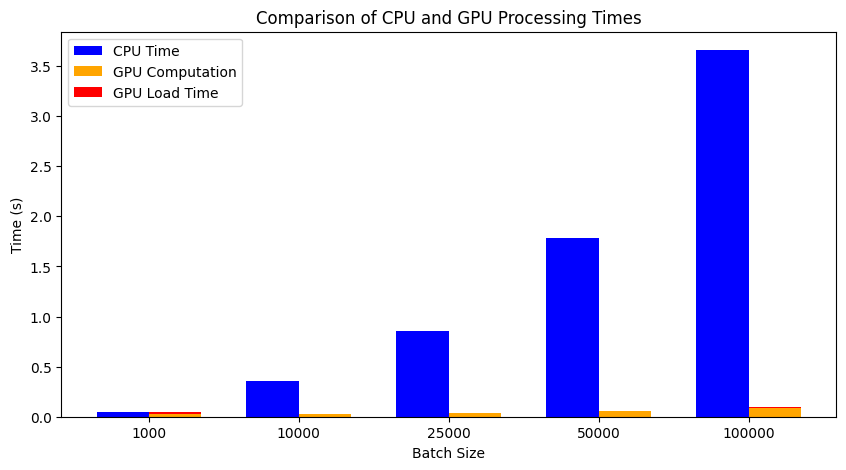

In [106]:
import matplotlib.pyplot as plt
import numpy as np

# Example Data
batch_sizes = ns # Batch sizes
cpu_times = ts_cpu  # Time on CPU
gpu_load_times = ts_gpu_load  # Time to load data to GPU
gpu_total_times = ts_gpu_total  # Total time on GPU (including load time)

x = np.arange(len(batch_sizes))  # X positions for the groups
width = 0.35  # Width of bars

# Create figure
fig, ax = plt.subplots(figsize=(10, 5))

# Plot CPU times
ax.bar(x - width/2, cpu_times, width, label='CPU Time', color='blue')

# Plot GPU computation time (total - load time)
ax.bar(x + width/2, np.array(gpu_total_times) - np.array(gpu_load_times), width, label='GPU Computation', color='orange')

# Plot GPU load time as a stacked part
ax.bar(x + width/2, gpu_load_times, width, bottom=np.array(gpu_total_times) - np.array(gpu_load_times), label='GPU Load Time', color='red')

# Labels and formatting
ax.set_xticks(x)
ax.set_xticklabels(batch_sizes)
ax.set_xlabel("Batch Size")
ax.set_ylabel("Time (s)")
ax.set_title("Comparison of CPU and GPU Processing Times")
ax.legend()

plt.show()


In [2]:
import json
with open("model_config.json", "r") as f:
    model_config = json.load(f)
data

{'n_qubits': 6, 'n_lin_layers': 2, 'n_quantum_layers': 4}

In [ ]:
data = dataset.input_kmers[:100]


In [27]:
lines = []
for i, k in enumerate(data):
    lines.append(f"> {i}\n")
    lines.append(f"{k}\n")

In [28]:
with open('test.fasta', 'w') as o:
    o.writelines(lines)

In [1]:
import os
parent = os.getcwd()
os.chdir('docker')

In [2]:
from run_model import *

out = main('../test.fasta', '../test_out.json')

/home/illia/miniconda3/envs/ppi/lib/python3.11/site-packages/torch/cuda/__init__.py:129: UserWarning: CUDA initialization: CUDA unknown error - this may be due to an incorrectly set up environment, e.g. changing env variable CUDA_VISIBLE_DEVICES after program start. Setting the available devices to be zero. (Triggered internally at /pytorch/c10/cuda/CUDAFunctions.cpp:109.)
  return torch._C._cuda_getDeviceCount() > 0


In [3]:
out

defaultdict(dict,
            {' 0': {'probs': array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
                      0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
                      0,  0,  0,  0,  0,  0,  0,  0,  0, 25, 73,  0,  0,  0,  0,  0,  0,
                      0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0], dtype=int32),
              'matched_100mer_indexes': [43, 44],
              'approximate_exact_position(s)': [4374]},
             ' 1': {'probs': array([ 0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
                      0,  0,  0,  0,  0,  0,  0,  0,  0, 45, 53,  0,  0,  0,  0,  0,  0,
                      0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,
                      0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0,  0], dtype=int32),
              'matched_100mer_indexes': [26, 27],
              'approximate_exact_position(s)': [2654]},
             ' 2': {'probs': a